## Revenue vs Profit: A Data-Driven Analysis of Retail Discount Strategy

**Business Problem:**

In this competitive world we often see companies providing discounts in order to attract customers and increase sales. However, excessive or uncontrolled discounting can silently vanish the company's profit margins & give birth to a situation where higher revenues does not translate into sustainable profitablility.
Live examples : Doodhwala, Shuttl

This project investigates a retail sales dataset to understand whether the company’s pricing strategy is helping or hurting overall profitability.

The key business question explored in this analysis is:

“Do discount-driven sales actually improve business performance, or they destroy profitability?”

**Key objectives include:**

• Understanding revenue and sales trends over time

• Evaluating the impact of discounting on profit margins

• Identifying high-performing and underperforming product categories

• Estimating price sensitivity using elasticity analysis

## Initial Analysis

# Import libraries required

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## Read the dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/babukulkarni/sales-data/sales_data.csv")
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


## check count of rows and columns

In [4]:
df.shape

(1000, 14)

## Check datatype of each colummn

In [ ]:
df.info()

In [ ]:
df.describe()

## Check sum of null/missing values across all the columns

In [ ]:
df.isna().sum()

## Feature Engineering
A profit column is generated using the data under unit_price, unit_cost & quantity sold.
This enables analysis of profit across regions and product categories.

In [59]:
# If discount is percentage like 10 meaning 10%
# convert to decimal if needed
if df['Discount'].max() > 1:
    df['Discount'] = df['Discount'] / 100
df.head(5)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,...,Profit,Margin_%,Profit_no_Discount,Discount_Impact,BreakEven_Discount,Capped_Discount,New_Selling_Price,New_Profit_per_Unit,New_Total_Profit,Discount_Bucket
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,...,1627.5636,37.183915,2060.46,432.8964,0.428374,0.090000,243.1702,90.4202,1627.5636,5-10%
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,...,-1189.8028,-1.868150,6681.85,7871.6528,0.093373,0.093373,3816.3900,0.0000,0.0000,10-15%
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,...,1066.8000,11.968228,3295.20,2228.4000,0.295746,0.200000,297.1200,35.5600,1066.8000,15-20%
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,...,1886.2350,1.104629,5371.08,3484.8450,0.030825,0.020000,4378.3950,48.3650,1886.2350,0-5%
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,...,-0.9984,-0.012051,719.42,720.4184,0.079889,0.079889,637.3700,0.0000,0.0000,5-10%


In [10]:
# Effective selling price
df['Effective_Unit_Price'] = df['Unit_Price'] * (1 - df['Discount'])
df

# Revenue recalculation (optional validation)
df['Calculated_Revenue'] = df['Effective_Unit_Price'] * df['Quantity_Sold']
df


 ## Profit per transaction 
df['Profit'] = (df['Effective_Unit_Price']- df['Unit_Cost']) * df['Quantity_Sold']
df

## Margin 
df['Margin_%'] = (df['Profit'] / df['Calculated_Revenue']) * 100
df

## Profit without discount
df['Profit_no_Discount'] = (df['Unit_Price']- df['Unit_Cost']) * df['Quantity_Sold']
df

## DIscount impact on profit 
df['Discount_Impact'] = df['Profit_no_Discount'] - df['Profit']
df


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Effective_Unit_Price,Calculated_Revenue,Profit,Margin_%,Profit_no_Discount,Discount_Impact
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,243.1702,4377.0636,1627.5636,37.183915,2060.46,432.8964
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,3746.4016,63688.8272,-1189.8028,-1.868150,6681.85,7871.6528
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,297.1200,8913.6000,1066.8000,11.968228,3295.20,2228.4000
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,4378.3950,170757.4050,1886.2350,1.104629,5371.08,3484.8450
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,637.2932,8284.8116,-0.9984,-0.012051,719.42,720.4184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,2023-04-15,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie,3863.9265,15455.7060,-4316.4140,-27.927640,1996.48,6312.8940
996,1067,2023-09-07,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob,1466.5560,54262.5720,-10647.2680,-19.621753,3776.96,14424.2280
997,1018,2023-04-27,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David,411.9738,7003.5546,956.3146,13.654703,1403.35,447.0354
998,1100,2023-12-20,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David,3705.9561,144532.2879,816.1179,0.564661,2276.04,1459.9221


In [12]:
df[['Unit_Price','Unit_Cost']].describe()

,Unit_Price,Unit_Cost
count,1000.000000,1000.000000
mean,2728.440120,2475.304550
std,1419.399839,1417.872546
min,167.120000,60.280000
25%,1509.085000,1238.380000
50%,2696.400000,2467.235000
75%,3957.970000,3702.865000
max,5442.150000,4995.300000


In [13]:
df['Discount'].describe()

count    1000.00000
mean        0.15239
std         0.08720
min         0.00000
25%         0.08000
50%         0.15000
75%         0.23000
max         0.30000
Name: Discount, dtype: float64

In [14]:
(df['Discount'] > ((df['Unit_Price'] - df['Unit_Cost']) / df['Unit_Price'])).mean()

np.float64(0.604)

The above result gives us percentage transactions where discount > gross margin.
We can see that around 60.4% of sales are above gross margin levels, which signal us the issue with pricig model.

# Rep wise total sales amount

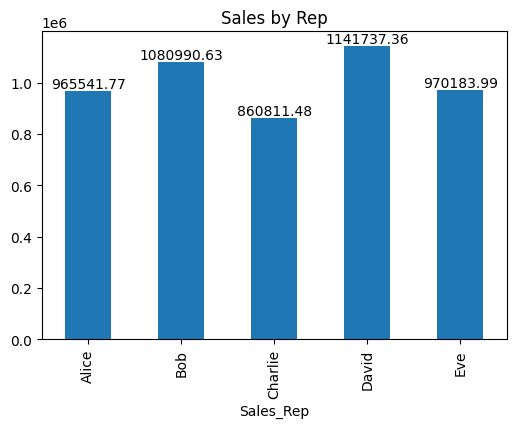

In [15]:
# Sales by sales Rep
rep_sales = df.groupby("Sales_Rep")["Sales_Amount"].sum()

sales_by_rep = rep_sales.plot(
    kind = "bar",
    title = "Sales by Rep",
    figsize = (6,4)
)

# Adding value labels on top of bars
for i, value in enumerate(rep_sales):
    sales_by_rep.text(i,value,str(round(value,2)),
                      ha='center', va='bottom')
plt.show()


# Sales by Product Category

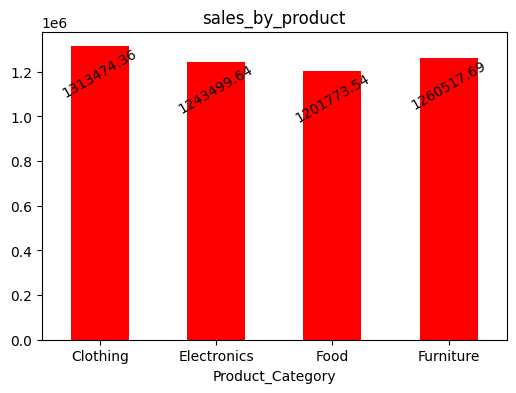

In [16]:
## Sales by Product category
Prod_category = df.groupby("Product_Category")["Sales_Amount"].sum()

Product_category = Prod_category.plot(
    kind = 'bar',
    title = 'sales_by_product',
    figsize = (6,4),
    color = 'red'
)
# Rotate x-axis labels
plt.xticks(rotation=360)

#Adding values 
for i,v in enumerate(Prod_category):
    Product_category.text(i,v,str(round(v,2)),
                         ha = "center", va = "top",rotation = 30)

plt.show()

# Region-Level Strategic Summary

In [18]:
region_summary = df.groupby('Region').agg(
    Total_Revenue = ('Calculated_Revenue', 'sum'),
    Total_Profit = ('Profit','sum'),
    Avg_Margin = ('Margin_%','mean'),
    Total_Discount_Impact = ('Discount_Impact','sum')
).reset_index()

region_summary['Profit_per_Discount_Loss']= (
    region_summary['Total_Profit'] / region_summary ['Total_Discount_Impact'].replace(0,np.nan)
)
region_summary.sort_values(by = 'Total_Profit', ascending = False)

,Region,Total_Revenue,Total_Profit,Avg_Margin,Total_Discount_Impact,Profit_per_Discount_Loss
2,South,1.389466e+07,-8.681700e+05,-0.674827,2.387907e+06,-0.363569
1,North,1.557034e+07,-9.766005e+05,-2.249434,2.638062e+06,-0.370196
3,West,1.501889e+07,-1.086588e+06,-1.643903,2.742680e+06,-0.396178
0,East,1.520228e+07,-1.224562e+06,-3.827251,2.875119e+06,-0.425917


Though we have considerable revenue but Total_profit margina are negative across all the product categories.

# Region wise profit margin

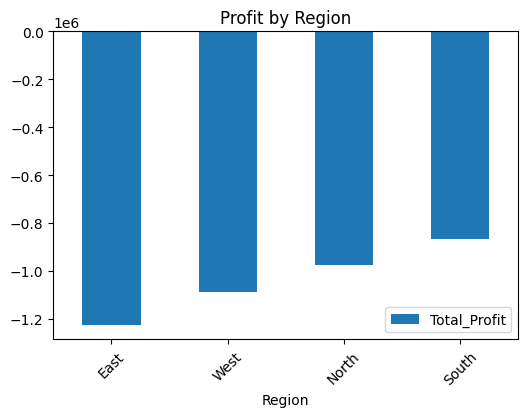

In [19]:
region_summary.sort_values('Total_Profit').plot(
    x = 'Region',
    y = 'Total_Profit',
    kind = 'bar',
    figsize = (6,4),
    title = 'Profit by Region'
)

plt.xticks(rotation = 45)
plt.show()


## Sales REP Efficiency

In [21]:
rep_summary = df.groupby('Sales_Rep').agg(
    Revenue = ('Calculated_Revenue','sum'),
    Profit = ('Profit', 'sum'),
    Avg_Discount = ('Discount', 'mean'),
    Avg_Margin = ('Margin_%', 'mean')).reset_index()
rep_summary.sort_values(by = 'Profit', ascending = False)

,Sales_Rep,Revenue,Profit,Avg_Discount,Avg_Margin
0,Alice,1.147665e+07,-6.262625e+05,0.141094,-0.546820
2,Charlie,9.827691e+06,-6.531650e+05,0.155148,-1.977190
1,Bob,1.176870e+07,-7.731242e+05,0.142404,-1.436783
4,Eve,1.293872e+07,-8.839436e+05,0.157512,-3.504606
3,David,1.367441e+07,-1.219425e+06,0.164595,-3.109644


**From above reults we can make out who is the one offering highest dicounts with lowest margins.**

## Plot Margin vs Revenue 

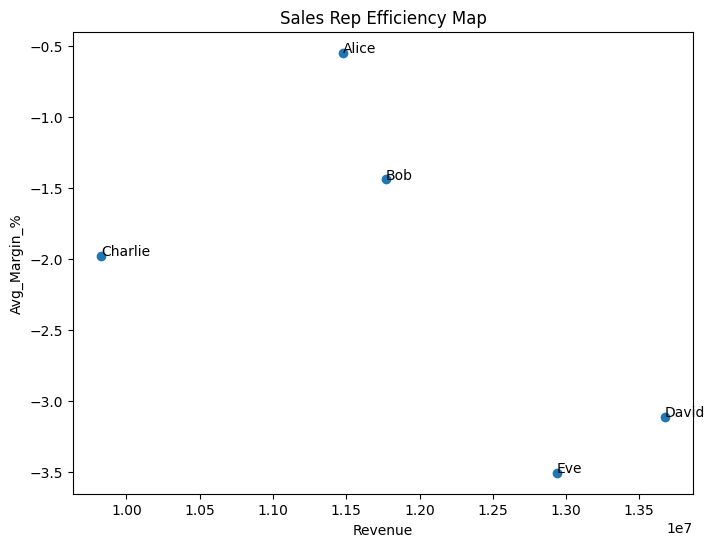

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(rep_summary['Revenue'], rep_summary['Avg_Margin'])

for i, txt in enumerate(rep_summary['Sales_Rep']):
    plt.annotate(txt,(rep_summary['Revenue'][i],rep_summary['Avg_Margin'][i]))

plt.xlabel("Revenue")
plt.ylabel("Avg_Margin_%")
plt.title("Sales Rep Efficiency Map")
plt.show()

The chart plots Revenue Vs Margin WRT representative performance.
We can see Eve has highest revenue with worst margin 
Alice with moderate revenue with moderate losses.
This indiactes us the rep with highest revnue + worst margin are pushing the products by discounting heavily.

Key takeaway
The data shows the high-performing reps with in revenue terms are largest contributors of margin losses.
Revenue growth is achieved at the cost of profitability.

# Category ROI

In [23]:
Category_summary = df.groupby('Product_Category').agg(
    Revenue = ('Calculated_Revenue','sum'),
    Profit = ('Profit','sum'),
    Avg_Margin = ('Margin_%','mean'),
    Avg_Discount = ('Discount','mean')
).reset_index()

Category_summary.sort_values(by='Profit', ascending = False)

,Product_Category,Revenue,Profit,Avg_Margin,Avg_Discount
1,Electronics,1.515323e+07,-8.434952e+05,-0.191308,0.136504
2,Food,1.280833e+07,-9.124514e+05,-2.246075,0.153805
3,Furniture,1.536378e+07,-1.187042e+06,-2.405907,0.158115
0,Clothing,1.636084e+07,-1.212932e+06,-3.658875,0.160224


**Insights:** **Here we can observe the revenue the in postive where as profit and avg_margin are in negative values which signals us they are burning money. This is not a product problem but a pricing probleme.Negative avg_margin indicates us the company is selling below average cost of the product.More sales = More Losses.**


## Plot Profit vs Discount

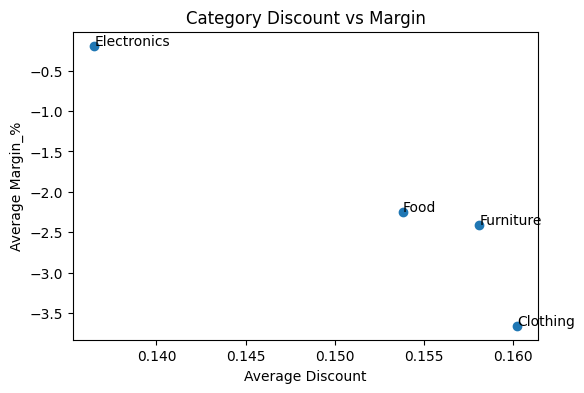

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(Category_summary['Avg_Discount'],Category_summary ['Avg_Margin'])

for i, txt in enumerate(Category_summary['Product_Category']):
    plt.annotate(txt,(Category_summary['Avg_Discount'][i],Category_summary['Avg_Margin'][i]))

plt.xlabel("Average Discount")
plt.ylabel("Average Margin_%")
plt.title("Category Discount vs Margin")
plt.show()

**Interpretation =** 
The margin and discount have negative relationship.
Clothing segment is margin destructive which means it is returning lowest margin at highest discount rates and Electronics segment is protecting by controlled disounts.

In [25]:
total_revenue = df['Calculated_Revenue'].sum()

region_summary['Revenue_Share_%'] = (
    region_summary['Total_Revenue'] / total_revenue
) * 100

region_summary.sort_values(by='Revenue_Share_%', ascending=False)

,Region,Total_Revenue,Total_Profit,Avg_Margin,Total_Discount_Impact,Profit_per_Discount_Loss,Revenue_Share_%
1,North,1.557034e+07,-9.766005e+05,-2.249434,2.638062e+06,-0.370196,26.087017
0,East,1.520228e+07,-1.224562e+06,-3.827251,2.875119e+06,-0.425917,25.470358
3,West,1.501889e+07,-1.086588e+06,-1.643903,2.742680e+06,-0.396178,25.163095
2,South,1.389466e+07,-8.681700e+05,-0.674827,2.387907e+06,-0.363569,23.279529


In [26]:
top2_share = region_summary.sort_values(
    by='Revenue_Share_%',
    ascending=False
).head(2)['Revenue_Share_%'].sum()

print("Top 2 Regions Revenue Share:", round(top2_share,2), "%")

Top 2 Regions Revenue Share: 51.56 %


## Time Trend

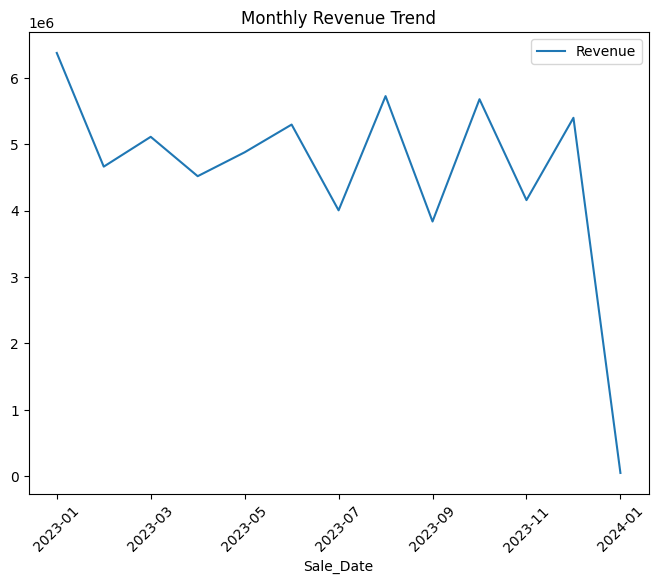

In [27]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

monthly_trend = df.groupby(
    df['Sale_Date'].dt.to_period('M')).agg(
        Revenue = ('Calculated_Revenue','sum'),
        Profit = ('Profit', 'sum')
    ).reset_index()

monthly_trend['Sale_Date'] = monthly_trend['Sale_Date'].astype(str)

monthly_trend.plot(
    x='Sale_Date',
    y='Revenue',
    kind ='line',
    figsize =(8,6),
    title ='Monthly Revenue Trend'
)
plt.xticks(rotation =45)
plt.show()

**Insight:**   The graph signals us the revenue is inconsistant and volatile.

This can be due to seasonal demand variations.

# As we have sees some analysis above now we shall focus on correlation between some metrics.

# Correlation B/W Dicount & Quantity_Sold

In [28]:
# Correlation between Discount & Quantity_Sold

df.groupby("Product_Category").apply(
    lambda x: x["Discount"].corr(x["Quantity_Sold"]),
include_groups = False)

Product_Category
Clothing      -0.087138
Electronics    0.040830
Food          -0.062348
Furniture      0.066986
dtype: float64

**We can infer from the above relation that clothing and Food have negative relation which means more discount leads to loss of quantity_sold which indicates us the customers are not discount centric or not price sensitive which is good for any business.**

In [29]:
# Correlation between Disocunt & Sales_Amount
df.groupby("Product_Category").apply(
    lambda x: x["Discount"].corr(x["Sales_Amount"]),
include_groups = False)

Product_Category
Clothing       0.097674
Electronics   -0.070285
Food           0.026679
Furniture      0.034610
dtype: float64

**Here also we can observe bare relation between the metrics compared above. Discounting does not move the sales_amount (No increase in sales)**

In [30]:
# Correlation between Dicount & Profit
df.groupby("Product_Category").apply(
    lambda x: x["Discount"].corr(x["Profit"]),
include_groups = False)

Product_Category
Clothing      -0.522637
Electronics   -0.548464
Food          -0.591193
Furniture     -0.558911
dtype: float64

**Here also we can observe cositent behavior as above.**


**SO FINALLY WE CAN SAY FROM ABOVE CORRELATION CALCULATIONS THAT THE CUSTOMERS ARE NOT DISCOUNT-DRIVEN.THE PROFITS ARE DISCOUNT DESTROYED.(THE COMPANY IS LOSING MONEY IN THE NAME OF DISCOUNT)**

**DICOUNTING SIGNIFICANTLY INCREASE NEITHER QUANTITY_SOLD NOR REVENUE. DISCOUNTING STRONGLY DESTROYING PROFIT.**



## So far we have understood all the relation between important metrics, now we shall find out break-even point discount value which is max discount allowed per category.


We have data of unit_cost, unit_price & discount value given.
break even happens when

unit_price(Sellig_price) = unit cost(margin = zero)

Unit_price(1-d) = unit_cost 1-d = (unit_cost)/(unit_price)

d(MAX_DISCOUNT) = (1) - (unit_cost / unit_price)

In [31]:
df["BreakEven_Discount"] = 1 - (df["Unit_Cost"] / df["Unit_Price"])
df["BreakEven_Discount"].head(10)

0    0.428374
1    0.093373
2    0.295746
3    0.030825
4    0.079889
5    0.185918
6    0.082040
7    0.066119
8    0.326249
9    0.169251
Name: BreakEven_Discount, dtype: float64

In [32]:
df.groupby("Product_Category")["BreakEven_Discount"].mean()

Product_Category
Clothing       0.138221
Electronics    0.142849
Food           0.144582
Furniture      0.145757
Name: BreakEven_Discount, dtype: float64

In [33]:
category_discount_analysis = df.groupby("Product_Category")[["BreakEven_Discount", "Discount"]].mean()

category_discount_analysis

,BreakEven_Discount,Discount
Product_Category,,
Clothing,0.138221,0.160224
Electronics,0.142849,0.136504
Food,0.144582,0.153805
Furniture,0.145757,0.158115


**THE ABOVE OBSERVATION MAKES US CLEAR THAT THE 'ELECTRONICS' IS THE ONLY PRODUCT THAT IS BEING SOLD BELOW THRESHOLD DISCOUNT VALUE WHICH IS WHY IT IS THE ONLY PRODUCT WITH SUFFERS THE LEAST.**

**THE 3 SEGMENTS OTHER THAN ELECTRONICS HAVE MOST PRICES BELOW THEIR UNIT COST**

**THE COMPANY IS NOT LOSING BECAUSE OF LOW DEMAND, IT IS LOSING DUE TO UNCONTROLLED DISCOUNT POLICIES FOLLOWED WITH THE 3 SEGMENTS EXCEPT ELECTRONICS**

NOW LET'S SEE WHAT HAPPENS IF WE CAP THE DISCOUNT VALUE FOR EACH CATEGORY
HERE WE WILL BE JUST REPLACING ACTUAL DISCOUNT WITH OUR BREAKEVEN DISCOUNT VALUE.

ASSUMING QUANTITY_SOLD SAME

In [34]:
df["Capped_Discount"] = df[["Discount", "BreakEven_Discount"]].min(axis=1)

In [35]:
# RECALCULATE SELLING PRICE

df["New_Selling_Price"] = df["Unit_Price"] * (1 - df["Capped_Discount"])

In [36]:
#RECALCULATE PROFIT PER UNIT 

df["New_Profit_per_Unit"] = df["New_Selling_Price"] - df["Unit_Cost"]

In [37]:
# RECALCULATE TOTAL PROFIT
df["New_Total_Profit"] = df["New_Profit_per_Unit"] * df["Quantity_Sold"]

In [38]:
# COMPARE OLD VS NEW 

old_profit = df["Sales_Amount"] - (df["Unit_Cost"] * df["Quantity_Sold"])
new_profit = df["New_Total_Profit"]

print("Old Total Profit:", old_profit.sum())
print("New Total Profit:", new_profit.sum())
print("Profit Improvement:", new_profit.sum() - old_profit.sum())

Old Total Profit: -58822828.41
New Total Profit: 1796337.1168
Profit Improvement: 60619165.5268



**YES!!!! THIS MAKES US CLEAR THAT THE LOSSES WERE NOT PRODUCT-DRIVEN, DEMAND-DRIVEN.THE LOSSES WERE PURELY CAUSED DUE DUE TO EXCESSIVE DISCOUTING OF THE PRODCTS(BASICALLY SELLING BELOW THEIR COST PRICE). THE PRICING CROSSED THE THRESHOLD DISCOUNT PRICE. JUST A SAMLL TWEEK IN THE DISCOUNT VALUES ALONE WOULD CONVERT COSIDERABLE AMOUNT IN THE PROFITS**


Now let's calculate how much apetite does the comapny have before profit become zero.

If the quantity drop by X %

break-even happens at 

NEW_PROFIT(1-X) = 0

THIS SIMPLY IMPLIES X = 100%
lets consider a concept of unit economics here.
CPU - contribution per unit, this is nothing but how much does a companuy make money by selling one unit of product.

CPU = unit_price(1-d) - unit_cost 

Profit = (new_selling_price - unit_cost) * quantity

if quantity drops by 10% thrn,
profit = (new_selling_price - unit_cost) * (quantity x 0.9)
"" IF CPU IS SMALL THEN PROFIT IS FRAGILE/SENSITIVE "" 


By below template we are calculating at what value of quantity drop the profit becomes negative, by that we can conclude that the comapny can't afford quantity drop below that value.

In [40]:

drop_rates = np.arange(0, 1.0, 0.05)

results = []

for drop in drop_rates:
    
    simulated_quantity = df["Quantity_Sold"] * (1 - drop)
    
    simulated_profit = (
        (df["New_Selling_Price"] - df["Unit_Cost"]) 
        * simulated_quantity
    ).sum()
    
    results.append((drop, simulated_profit))

import pandas as pd
sensitivity_df = pd.DataFrame(results, columns=["Volume_Drop_%", "Simulated_Profit"])

sensitivity_df

,Volume_Drop_%,Simulated_Profit
0,0.00,1.796337e+06
1,0.05,1.706520e+06
2,0.10,1.616703e+06
3,0.15,1.526887e+06
4,0.20,1.437070e+06
5,0.25,1.347253e+06
6,0.30,1.257436e+06
7,0.35,1.167619e+06
8,0.40,1.077802e+06
9,0.45,9.879854e+05


From above result we can say that Profit is decreasing linearly and never becoming negative.
Even after capping at break-even, our contribution per unit is positive on average, not zero, which is why why even at 95% volume drop, profit is still positive.

We can interprete theoretically company can losE 100% before profit become zero.

FINAL VERDICT ---


THE COMPANY'S LOSSES ARE
* NOT MARKET-DRIVEN REACTIONS.
* NOT DUE TO WEAK DEMAND
* LOSSES ARE DUE TO NEGATIVE UNIT CONTRIBUTION I.E OVER DISCOUNTING OF THE PRICE ,ONCE THE PRICING IS PROPERLY RESTORED THE PROFITS WILL BE RECOVERED SIGNIFICANTLY.

RECOMMENDATIONS:

* REINFORCE CORRECT PRICING POLICY.
* NEVER OVER EXCEED DISCOUNTS OVER BREAK-EVEN POINT, ENFORCE CAP ON DISCOUNT PER CATEGORY/SEGMENT
* CONCENTRATE ON UNIT ECONOMICS
  GROWTH WITHOUT CPU IS DISASTROUS TO THE COMPANY AS WELL AS TO THE PRODUCT

Now let's understand product wise elasticity using a simple regression model and simulate profit.

Elasticity basically means 1% of change in price leads to how much change in the quantity ?


In [43]:
# Aggregate by category (example for Clothing)
df_cat = df[df["Product_Category"] == "Clothing"]

# Remove zero or negative values
df_cat = df_cat[(df_cat["Quantity_Sold"] > 0) & (df_cat["Unit_Price"] > 0)]

# Log transform
df_cat["log_Q"] = np.log(df_cat["Quantity_Sold"])
df_cat["log_P"] = np.log(df_cat["Unit_Price"])

# Regression
X = sm.add_constant(df_cat["log_P"])
model = sm.OLS(df_cat["log_Q"], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  log_Q   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.741
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0541
Time:                        07:00:28   Log-Likelihood:                -311.56
No. Observations:                 268   AIC:                             627.1
Df Residuals:                     266   BIC:                             634.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0260      0.522      3.884      0.0

From above summary we can deduce that the elasticity for clothing segment is around 13%.(which ideally be negative). So here Price up = quantity up 
So this signals us one of the below.

• Pricing is not driving demand
• Discounts dominate price behavior
• Customers buy based on category need, not price

Since p-value is 0.054, relationship is not significant.

R-sqr(R2) = 0.014 (only impact of1.4%)

So key takeaway:
Companies should focus on
discount discipline, pricing governance

In [44]:
# your improved profit after pricing correction
new_profit = 1796337.1168

volume_drop = np.arange(0,1,0.05)

simulation = pd.DataFrame({
    "Volume_Drop_%": volume_drop,
    "Simulated_Profit": new_profit * (1 - volume_drop)
})

simulation.head()

,Volume_Drop_%,Simulated_Profit
0,0.00,1.796337e+06
1,0.05,1.706520e+06
2,0.10,1.616703e+06
3,0.15,1.526887e+06
4,0.20,1.437070e+06


**How much demand can we afford to lose after reducing discount and still remain profitable.**

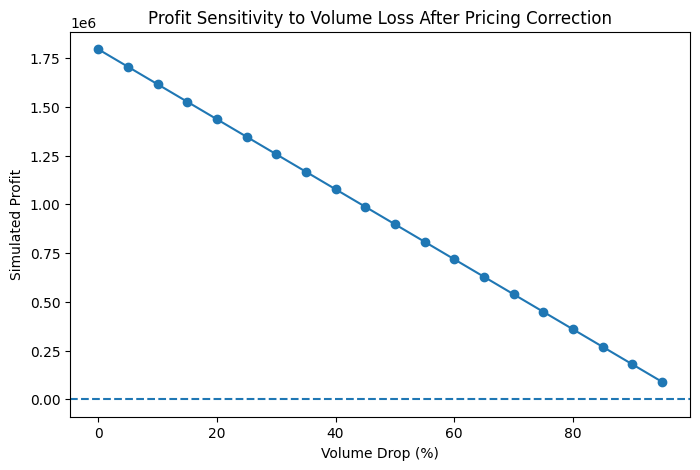

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(simulation["Volume_Drop_%"]*100,
         simulation["Simulated_Profit"],
         marker='o')

plt.axhline(0, linestyle='--')

plt.xlabel("Volume Drop (%)")
plt.ylabel("Simulated Profit")
plt.title("Profit Sensitivity to Volume Loss After Pricing Correction")

plt.show()

It is evident from the above plot even if sales drop the company remains profitable due to restored unit economoics(discount changed to break-even point). This shows us company was operating with negative unit economics which was due to excess discounting

# Dicount Vs Profit  plot

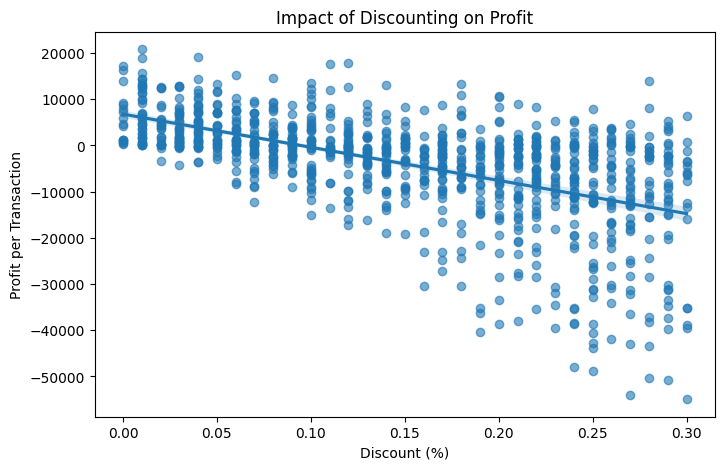

In [46]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="Discount",
    y="Profit",
    data=df,
    scatter_kws={"alpha":0.6}
)

plt.title("Impact of Discounting on Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit per Transaction")

plt.show()

The scatter plot shows a clear negative relationship between discount levels and transaction profitability. As discount percentages increase, profit per transaction declines sharply, confirming that aggressive discounting

/tmp/ipykernel_55/106153655.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_profit = df.groupby("Discount_Bucket")["Profit"].mean()


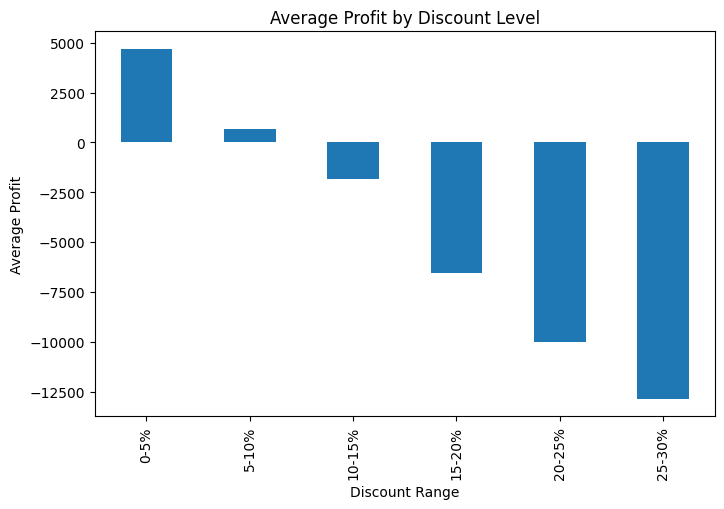

In [47]:
df["Discount_Bucket"] = pd.cut(
    df["Discount"],
    bins=[0,0.05,0.1,0.15,0.2,0.25,0.3],
    labels=["0-5%","5-10%","10-15%","15-20%","20-25%","25-30%"]
)

bucket_profit = df.groupby("Discount_Bucket")["Profit"].mean()

bucket_profit.plot(kind="bar", figsize=(8,5))

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit")

plt.show()

This is makes evident again that as discount is increased, average profit decreasess.

Now we shall conclude all the insights and takeways from the dataset.

1. Revenue growth is driven by dicounting.
Despite strong revenue numbers all the regions faced reduced profit margins(negative). Analysis shows that excessive dicouting has led the company to sell the products below unit_price which has led to significant reduced contribution margins.

Takeaway
Revenue alone is not a reliable performance indicator when pricing discipline is weak.

2. Clothing Category Is the Largest Margin Destroyer.

3. Discounts strongly destroy profitability.
Correelation analysis showed us a negative relationship between discount values and profit across all segments, so we can say that over dicounting does not increase profits.

4. Current Pricing policies followed breaks unit economics.
As we saw in our analysis of break-even discount analysis average discounts in many segements exceeded the minimum viable discount levels due to which the company is in negetive margins even after increased revenue volumnes and we could see that just reinforcing discount level equal to break-even point there was significant increase in the profit values.
So we can say thata from this example that profitability improvement does not require increasing sales — it requires fixing pricing models


FINAL VERDICT ---

THE COMPANY'S LOSSES ARE

NOT MARKET-DRIVEN REACTIONS.

NOT DUE TO WEAK DEMAND

LOSSES ARE DUE TO NEGATIVE UNIT CONTRIBUTION i.e OVER DISCOUNTING OF THE PRICE ,ONCE THE PRICING IS PROPERLY RESTORED THE PROFITS WILL BE RECOVERED SIGNIFICANTLY.

RECOMMENDATIONS:

REINFORCING CORRECT PRICING MODEL WOULD CORRECT THE PROFIT CALUES.

NEVER OVER EXCEED DISCOUNTS OVER BREAK-EVEN POINT, ENFORCE CAP ON DISCOUNT PER CATEGORY/SEGMENT.

CONCENTRATE ON UNIT ECONOMICS.

GROWTH WITHOUT CPU (CONTRIBUTION PER UNIT) IS DISASTROUS TO THE COMPANY AS WELL AS TO THE PRODUCT